<a href="https://colab.research.google.com/github/serjtankian/practica-keepcoding-NLP-Search/blob/main/Metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import joblib

lr_final = joblib.load('/content/drive/MyDrive/lr_final.pkl')
gb_final = joblib.load('/content/drive/MyDrive/gb_final.pkl')
cv = joblib.load('/content/drive/MyDrive/tfidf_vectorizer.pkl')
X_test_ = joblib.load('/content/drive/MyDrive/X_test.pkl')
y_test = joblib.load('/content/drive/MyDrive/y_test.pkl')

print("Modelos y datos cargados correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelos y datos cargados correctamente.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- Logistic Regression ---
y_pred_lr = lr_final.predict(X_test_)
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Negativo', 'Positivo']))

# --- Gradient Boosting ---
y_pred_gb = gb_final.predict(X_test_)
print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gb, target_names=['Negativo', 'Positivo']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Negativo       0.64      0.39      0.49       230
    Positivo       0.87      0.95      0.91      1016

    accuracy                           0.85      1246
   macro avg       0.76      0.67      0.70      1246
weighted avg       0.83      0.85      0.83      1246

=== Gradient Boosting ===
              precision    recall  f1-score   support

    Negativo       0.49      0.30      0.37       230
    Positivo       0.85      0.93      0.89      1016

    accuracy                           0.81      1246
   macro avg       0.67      0.62      0.63      1246
weighted avg       0.79      0.81      0.79      1246



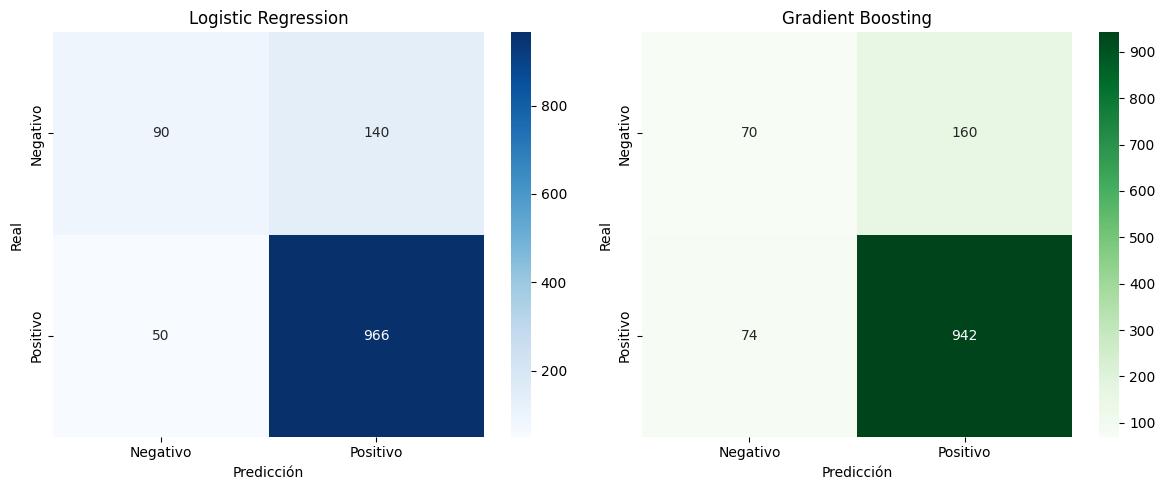

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'], ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'], ax=axes[1])
axes[1].set_title('Gradient Boosting')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

In [ ]:
f1_lr = f1_score(y_test, y_pred_lr)
f1_gb = f1_score(y_test, y_pred_gb)

print(f"F1-score Logistic Regression: {f1_lr:.4f}")
print(f"F1-score Gradient Boosting:   {f1_gb:.4f}")

mejor_modelo = "Logistic Regression" if f1_lr > f1_gb else "Gradient Boosting"
print(f"\nMejor modelo: {mejor_modelo}")

F1-score Logistic Regression: 0.9105
F1-score Gradient Boosting:   0.8895

Mejor modelo: Logistic Regression


## Conclusiones

**Modelo elegido:** Logistic Regressio,
basado en su F1-score de 0.91 /0.49 frente a 0.89/0.37 del otro modelo.

**Balance de clases:** El dataset se presentó desbalanceado. No se balanceo por falta de tiempo, pero en la situacion ideal debian ser la misma cantidad de reviwes positivas que negativas. Esto afectó las métricas para ambos mdoelos, observándose mayor precision, recall, f1-score en positivas que en negativas.



**Limitaciones:**
- El preprocesado elimino información de contexto al usar Bag-of-Words
  (no captura orden de palabras ni negaciones complejas como "not as good" por ejemplo)
- Se trabajó con un subset de 5mil reviews por razones de cómputo,
  lo que puede no representar toda la variabilidad del dataset completo

**Posibles mejoras:**
- Probar `class_weight='balanced'` en Logistic Regression para compensar desbalanceo
- Incorporar n-gramas (ngram_range=(1,2)) para capturar frases como "not good"
- Explorar Word Embeddings (Word2Vec) como representación alternativa a BoW